In [1]:

#from qmoo_files import load_problem
#from qmoo_plot import plot_graphs, plot_pareto_hv

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerOptions, SamplerV2
from qiskit.circuit import ParameterVector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from qiskit.transpiler import CouplingMap
from qiskit.circuit.library.standard_gates.equivalence_library import _sel
from qiskit_aer.primitives import SamplerV2 as SamplerAerV2

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
#from qopt_best_practices.transpilation import UnrollBoxes
#from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import generate_preset_qaoa_pass_manager

from matplotlib import pyplot as plt
from moocore import hypervolume, filter_dominated


import networkx as nx
import numpy as np

In [2]:
%pwd
%ls

1.ipynb                    __pycache__/             serverless/
2.ipynb                    fig/                     skqd_helpers.py
3_regular_static_80q/      qaoa_training_pipeline/  soa_42q/
Quantum-Challenge-Grader/  qc_grader/               soa_42q.zip
Untitled.ipynb             qopt_best_practices/


In [3]:
# Load your IBM Account
#vYozTXLb8r0KTpE7w_Qu0AdIwhALL8jDYvy5XTIRrQiu
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="7zcCGKSK04JJHU5tlcZGFHpd9cjw-oafZ4dmBgkjXIrB",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/813b37ffee14414ca81092ab94341434:9f2dbcc9-13c6-4e95-86d6-acf13b605994::",
    overwrite=True
    )

service = QiskitRuntimeService()
# PROMPT Define your prefered backend 

backend = service.least_busy(min_num_qubits=156)

print(f"Using backend {backend.name}")

management.get:WARNING:2026-06-30 22:22:56,038: Loading default saved account


Using backend ibm_cleveland


In [4]:
from qc_grader.challenges.r2p_2026_us import join_team
YOUR_TEAM_NAME="RPi_C_HelloWorld"
join_team(YOUR_TEAM_NAME)

management.get:WARNING:2026-06-30 22:22:59,187: Loading default saved account


Trying to join "RPi_C_HelloWorld", please wait...

You have joined "RPi_C_HelloWorld" 🎉
Any answers you submit from now on will be associated with this team.


In [5]:
# import sys 
# import os

# sys.path.append(os.path.abspath('/home/jovyan/qopt-best-practices/qopt_best_practices/transpilation/'))  
# # module_path = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'qopt-best-practices/qopt_best_practices/transpilation'))

# if module_path not in sys.path:
#     sys.path.append(module_path)

from qopt_best_practices.transpilation import UnrollBoxes
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import generate_preset_qaoa_pass_manager


In [6]:
from qc_grader.challenges.r2p_2026_us.lab_qmoo import (
    grade_lab_qmoo_ex1,
    grade_lab_qmoo_ex2,
    grade_lab_qmoo_ex3,
    grade_lab_qmoo_ex4)
from qc_grader.challenges.r2p_2026_us import check_progress

In [7]:
import glob
import json
import networkx as nx

def load_problem(dirfn, printtxt=True):
    graphsfn = dirfn + "problem_graph_*.json"
    anglefn = dirfn + "angles.json"
    upperfn = dirfn + "upper_bounds.json"
    lowerfn = dirfn + "lower_bounds.json"
    
    if printtxt:
        print("loading", graphsfn)

    try:
        graphs = []
        num_graphs = len(glob.glob(graphsfn))
        for i in range(num_graphs):
            f = dirfn + f"problem_graph_{i}.json"
            
            with open(f, 'r') as file:
                data = json.load(file)
                # Handle NetworkX 3.0+ compatibility: convert 'links' to 'edges'
                if 'links' in data and 'edges' not in data:
                    data['edges'] = data.pop('links')
                graphs.append(nx.node_link_graph(data))
        if len(graphs) != num_graphs:
            raise Exception

    except Exception as e:
        print("Wasn't able to load graphs from " + graphsfn + ", error:" + str(e))
        return None, None, None, None
    try:
        angles = json.load(open(anglefn, 'r'))
        if len(angles) == 0:
            raise Exception
    except Exception as e:
        print("Wasn't able to load QAOA angles from " + anglefn + ", error:" + str(e))
        return None, None, None, None
    try:
        upper = json.load(open(upperfn, 'r'))
        if len(upper) == 0:
            raise Exception
    except Exception as e:
        print("Wasn't able to load upper bounds from " + upperfn + ", error:" + str(e))
        return None, None, None, None

    try:
        lower = json.load(open(lowerfn, 'r'))
        if len(lower) == 0:
            raise Exception
    except Exception as e:
        print("Wasn't able to load lower bounds from " + lowerfn + ", error:" + str(e))
        return None, None, None, None
    return graphs, angles, upper, lower

In [8]:
import random
from matplotlib import pyplot as plt, patches as patches

def plot_pareto():
    plot_pareto_hv(hv=False)


def plot_pareto_hv(points=None, ref=None, hv=False, second=False):
    if points is None:
        points = [(0.05, 1.0), (0.35, 0.85), (0.5, 0.5), (0.85, 0.35), (1.0, 0.05)]
        points_cv = [(0.05, 1.0), (0.35, 0.85), (0.85, 0.35), (1.0, 0.05)]
    if ref is None:
        ref = (0, 0)

    fig, ax = plt.subplots(figsize=(5,5))

    ax.plot([x for x, _ in points], [y for _, y in points], color='lightblue', ls='--')

    #ax.plot([x for x, _ in points_cv], [y for _, y in points_cv], color='black', ls=':')


    for point in points:
        ax.plot(point[0], point[1], 'o', color='lightblue')  # Mark the top-right corner

    if hv:
        for point in points:
            width = point[0] - ref[0]
            height = point[1] - ref[1]

            rect = patches.Rectangle(ref, width, height, linewidth=1, facecolor='lightgreen')
            ax.add_patch(rect)
        if second:
            points = [(0.18,0.62), (0.37, 0.45), (0.45, 0.35), (0.62, 0.18)]
            for point in points:
                width = point[0] - ref[0]
                height = point[1] - ref[1]

                rect = patches.Rectangle(ref, width, height, linewidth=3, ls='--', facecolor='orange')
                ax.add_patch(rect)
                for point in points:
                    ax.plot(point[0], point[1], 'x', color='orange')  # Mark the top-right corner

    if not hv:
        random_points=[]
        num_random_points=120
        for _ in range(num_random_points):
            rect_point = random.choice(points)
            x = random.uniform(ref[0], rect_point[0])
            y = random.uniform(ref[1], rect_point[1])
            random_points.append((x, y))

        # Plot random points
        for x, y in random_points:
            ax.plot(x, y, 'o', color='lightblue')  # Black dots

    plt.ylabel('$f_2$')
    plt.xlabel('$f_1$')


def plot_graphs(moo_graphs):
    import networkx as nx
    import numpy as np  
    import copy

    fig, axes = plt.subplots(1, len(moo_graphs), figsize=(8 * len(moo_graphs), 6))
    for ax, G in zip(axes, moo_graphs):
        g = copy.deepcopy(G)
        for u, v in g.edges():
            g[u][v]['weight'] = 1
        pos = nx.kamada_kawai_layout(g, weight='weight')
        nx.draw(g, pos=pos, ax=ax, with_labels=True, node_size=150, font_size=9)#, node_size=30, font_size=6, width=10)

        weights = nx.get_edge_attributes(G, 'weight')
        for k, w in weights.items():
            weights[k] = np.round(w, 2)
        if len(g.nodes) < 80:
            nx.draw_networkx_edge_labels(g, ax=ax, pos=pos, edge_labels=weights, bbox=None, font_size=7)
        else:
            nx.draw_networkx_edge_labels(g, ax=ax, pos=pos, edge_labels=weights, bbox=None, font_size=3)
        ax.set_title(f'Graph $g_{moo_graphs.index(G)}$')
    plt.tight_layout()

def plot_hypervolumes_from_batch(hvs):
    import pandas as pd

    df = pd.DataFrame(hvs, columns=["Hypervolume"]).describe()    
    plt.hist(hvs)

In [9]:
"""Annotated QAOA Ansatz builder"""

from __future__ import annotations

import itertools
import typing
import warnings
from collections.abc import Sequence

import numpy as np
from qiskit import __version__ as qiskit_version
from qiskit.circuit import QuantumCircuit, annotation
from qiskit.circuit.parametervector import ParameterVector
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
from qiskit.quantum_info.operators.base_operator import BaseOperator

if typing.TYPE_CHECKING:
    from qiskit.synthesis.evolution import EvolutionSynthesis

#from .pauli_evolution import PauliEvolutionGate  # pylint: disable=wrong-import-position


class CostLayerAnnotation(annotation.Annotation):
    """Annotation for cost layer boxes. The payload indicates the QAOA layer id,
    which is expected to start counting at 1! (not 0)"""

    def __init__(self, layer_id: int):
        self.namespace = "qaoa.cost_layer"
        self.payload = str(layer_id)


class MixerAnnotation(annotation.Annotation):
    """Annotation for mixer boxes. The payload indicates the QAOA layer id,
    which is expected to start counting at 1! (not 0)"""

    def __init__(self, layer_id: int):
        self.namespace = "qaoa.mixer"
        self.payload = str(layer_id)


class InitStateAnnotation(annotation.Annotation):
    """Annotation for initial state boxes. This annotation automatically sets
    the QAOA layer id as there should only be one initial state per QAOA circuit."""

    def __init__(self):
        self.namespace = "qaoa.init_state"
        self.payload = str(1)


def _qiskit_version_tuple() -> tuple[int, int]:
    version_parts = qiskit_version.split(".")
    major = int(version_parts[0])
    minor_digits = []
    for character in version_parts[1]:
        if character.isdigit():
            minor_digits.append(character)
        else:
            break
    minor = int("".join(minor_digits)) if minor_digits else 0
    return major, minor


def annotated_evolved_operator_ansatz(  # pylint: disable=too-many-positional-arguments
    operators: BaseOperator | Sequence[BaseOperator],
    reps: int = 1,
    evolution: EvolutionSynthesis | None = None,
    insert_barriers: bool = False,
    name: str = "EvolvedOps",
    parameter_prefix: str | Sequence[str] = "t",
    remove_identities: bool = True,
    flatten: bool | None = None,
    annotations: Sequence[annotation.Annotation] | None = None,
) -> QuantumCircuit:
    r"""Construct an ansatz out of operator evolutions with a series of annotations

    For a set of operators :math:`[O_1, ..., O_J]` and :math:`R` repetitions (``reps``), this circuit
    is defined as

    .. math::

        \prod_{r=1}^{R} \left( \prod_{j=J}^1 e^{-i\theta_{j, r} O_j} \right)

    where the exponentials :math:`exp(-i\theta O_j)` are expanded using the product formula
    specified by ``evolution``.

    Examples:

    .. plot::
        :alt: Circuit diagram output by the previous code.
        :include-source:

        from qiskit.circuit.library import evolved_operator_ansatz
        from qiskit.quantum_info import Pauli

        ops = [Pauli("ZZI"), Pauli("IZZ"), Pauli("IXI")]
        ansatz = evolved_operator_ansatz(ops, reps=3, insert_barriers=True)
        ansatz.draw("mpl")

    Args:
        operators: The operators to evolve. Can be a single operator or a sequence thereof.
        reps: The number of times to repeat the evolved operators.
        evolution: A specification of which evolution synthesis to use for the
            :class:`.PauliEvolutionGate`. Defaults to first order Trotterization. Note, that
            operators of type :class:`.Operator` are evolved using the :class:`.HamiltonianGate`,
            as there are no Hamiltonian terms to expand in Trotterization.
        insert_barriers: Whether to insert barriers in between each evolution.
        name: The name of the circuit.
        parameter_prefix: Set the names of the circuit parameters. If a string, the same prefix
            will be used for each parameters. Can also be a list to specify a prefix per
            operator.
        remove_identities: If ``True``, ignore identity operators (note that we do not check
            :class:`.Operator` inputs). This will also remove parameters associated with identities.
        flatten: If ``True``, a flat circuit is returned instead of nesting it inside multiple
            layers of gate objects. Setting this to ``False`` is significantly less performant,
            especially for parameter binding, but can be desirable for a cleaner visualization.
        annotations: A series of box annotations. For qaoa circuits, the expected order of annotations is
            alternating cost and mixer on a per-layer basis, with a total of
            ``reps * len(operators)`` elements:

            ```
                annotations = [CostLayerAnnotation(layer_id=1),
                                MixerAnnotation(layer_id=1),
                                CostLayerAnnotation(layer_id=2),
                                MixerAnnotation(layer_id=2),
                                ...]
            ```
    """

    if reps < 0:
        raise ValueError("reps must be a non-negative integer.")

    if isinstance(operators, BaseOperator):
        operators = [operators]
    elif len(operators) == 0:
        return QuantumCircuit()

    num_operators = len(operators)
    if not isinstance(parameter_prefix, str):
        if num_operators != len(parameter_prefix):
            raise ValueError(
                f"Mismatching number of operators ({len(operators)}) and parameter_prefix "
                f"({len(parameter_prefix)})."
            )

    num_qubits = operators[0].num_qubits
    if remove_identities:
        operators, parameter_prefix = _remove_identities(operators, parameter_prefix)

    if any(op.num_qubits != num_qubits for op in operators):
        raise ValueError("Inconsistent numbers of qubits in the operators.")

    # get the total number of parameters
    if isinstance(parameter_prefix, str):
        parameters = ParameterVector(parameter_prefix, reps * num_operators)
        param_iter = iter(parameters)
    else:
        # this creates the parameter vectors per operator, e.g.
        #    [[a0, a1, a2, ...], [b0, b1, b2, ...], [c0, c1, c2, ...]]
        # and turns them into an iterator
        #    a0 -> b0 -> c0 -> a1 -> b1 -> c1 -> a2 -> ...
        per_operator = [ParameterVector(prefix, reps).params for prefix in parameter_prefix]
        param_iter = itertools.chain.from_iterable(zip(*per_operator))

    # slower, Python-path
    if evolution is None:
        from qiskit.synthesis.evolution import LieTrotter

        evolution = LieTrotter(insert_barriers=insert_barriers)

    circuit = QuantumCircuit(num_qubits, name=name)

    # pylint: disable=cyclic-import
    from qiskit.circuit.library.hamiltonian_gate import HamiltonianGate

    annot_index = 0
    for rep in range(reps):
        for i, op in enumerate(operators):
            if isinstance(op, Operator):
                gate = HamiltonianGate(op, next(param_iter))
                if flatten:
                    warnings.warn(
                        "Cannot flatten the evolution of an Operator, flatten is set to "
                        "False for this operator."
                    )
                flatten_operator = False

            elif isinstance(op, BaseOperator):
                gate = PauliEvolutionGate(op, next(param_iter), synthesis=evolution)
                flatten_operator = flatten is True or flatten is None
            else:
                raise ValueError(f"Unsupported operator type: {type(op)}")

            if flatten_operator:
                if annotations:
                    with circuit.box(annotations=(annotations[annot_index],)):
                        circuit.compose(gate.definition, inplace=True)
                    annot_index += 1
                else:
                    circuit.compose(gate.definition, inplace=True)

            else:
                if annotations:
                    with circuit.box(annotations=(annotations[annot_index],)):
                        circuit.append(gate, circuit.qubits)
                    annot_index += 1
                else:
                    circuit.append(gate, circuit.qubits)

            if insert_barriers and (rep < reps - 1 or i < num_operators - 1):
                circuit.barrier()

    return circuit


def _is_pauli_identity(operator):
    if isinstance(operator, SparsePauliOp):
        if len(operator.paulis) == 1:
            operator = operator.paulis[0]  # check if the single Pauli is identity below
        else:
            return False
    if isinstance(operator, Pauli):
        return not np.any(np.logical_or(operator.x, operator.z))
    return False


def _remove_identities(operators, prefixes):
    identity_ops = {index for index, op in enumerate(operators) if _is_pauli_identity(op)}

    if len(identity_ops) == 0:
        return operators, prefixes

    cleaned_ops = [op for i, op in enumerate(operators) if i not in identity_ops]
    cleaned_prefix = [prefix for i, prefix in enumerate(prefixes) if i not in identity_ops]

    return cleaned_ops, cleaned_prefix


def annotated_qaoa_ansatz(  # pylint: disable=too-many-positional-arguments
    cost_operator: BaseOperator,
    reps: int = 1,
    initial_state: QuantumCircuit | None = None,
    mixer_operator: BaseOperator | None = None,
    insert_barriers: bool = False,
    name: str = "QAOA",
    flatten: bool = True,
) -> QuantumCircuit:
    r"""A generalized annotated QAOA quantum circuit with a support of custom initial states and mixers.
        The annotations indicate the layer number, and whether the layer is a cost layer or a mixer.

    Examples:

        To define the QAOA ansatz we require a cost Hamiltonian, encoding the classical
        optimization problem:

        .. plot::
            :alt: Circuit diagram output by the previous code.
            :include-source:

            from qiskit.quantum_info import SparsePauliOp
            from qiskit.circuit.library import qaoa_ansatz

            cost_operator = SparsePauliOp(["ZZII", "IIZZ", "ZIIZ"])
            ansatz = qaoa_ansatz(cost_operator, reps=3, insert_barriers=True)
            ansatz.draw("mpl")

    Args:
        cost_operator: The operator representing the cost of the optimization problem, denoted as
            :math:`U(C, \gamma)` in [1].
        reps: The integer determining the depth of the circuit, called :math:`p` in [1].
        initial_state: An optional initial state to use, which defaults to a layer of
            Hadamard gates preparing the :math:`|+\rangle^{\otimes n}` state.
            If a custom mixer is chosen, this circuit should be set to prepare its ground state,
            to appropriately fulfill the annealing conditions.
        mixer_operator: An optional custom mixer, which defaults to global Pauli-:math:`X`
            rotations. This is denoted as :math:`U(B, \beta)` in [1]. If this is set,
            the ``initial_state`` might also require modification.
        insert_barriers: Whether to insert barriers in-between the cost and mixer operators.
        name: The name of the circuit.
        flatten: If ``True``, a flat circuit is returned instead of nesting it inside multiple
            layers of gate objects. Setting this to ``False`` is significantly less performant,
            especially for parameter binding, but can be desirable for a cleaner visualization.

    References:

        [1]: Farhi et al., A Quantum Approximate Optimization Algorithm.
            `arXiv:1411.4028 <https://arxiv.org/pdf/1411.4028>`_
    """
    num_qubits = cost_operator.num_qubits

    circuit = QuantumCircuit(num_qubits)
    with circuit.box(annotations=(InitStateAnnotation(),)):
        if initial_state is None:
            initial_state = QuantumCircuit(num_qubits)
            initial_state.h(range(num_qubits))
        circuit.compose(initial_state, inplace=True)

    if mixer_operator is None:
        mixer_operator = SparsePauliOp.from_sparse_list(
            [("X", [i], 1) for i in range(num_qubits)], num_qubits
        )

    parameter_prefix = ["γ", "β"]

    annotations = []
    for layer_id in range(1, reps + 1):
        annotations += [CostLayerAnnotation(layer_id), MixerAnnotation(layer_id)]
    out_circuit = circuit.compose(
        annotated_evolved_operator_ansatz(
            [cost_operator, mixer_operator],
            reps=reps,
            insert_barriers=insert_barriers,
            parameter_prefix=parameter_prefix,
            name=name,
            flatten=flatten,
            annotations=annotations,
        ),
        copy=False,
    )

    # Prior to Qiskit 2.4, disconnected graphs could create boxes acting on subsets of qubits.
    # Keep the legacy validation only for those versions. Boxes with 0 qubits are allowed for
    # dummy mixers.

    if _qiskit_version_tuple() < (2, 4):
        for inst in out_circuit:
            if inst.operation.name == "box":
                if inst.operation.num_qubits not in (0, out_circuit.num_qubits):
                    raise NotImplementedError(
                        f"This constructor does not support disconnected graphs on "
                        f"Qiskit < 2.4. Expected instruction to act on "
                        f"{out_circuit.num_qubits}, instead, got "
                        f"{inst.operation.num_qubits}. Please update Qiskit."
                    )
    return out_circuit


In [10]:
# This code is part of Qiskit.
#
# (C) Copyright IBM 2021, 2024.
#
# This code is licensed under the Apache License, Version 2.0. You may
# obtain a copy of this license in the LICENSE.txt file in the root directory
# of this source tree or at http://www.apache.org/licenses/LICENSE-2.0.
#
# Any modifications or derivative works of this code must retain this
# copyright notice, and modified files need to carry a notice indicating
# that they have been altered from the originals.

"""A gate to implement time-evolution of operators."""

from __future__ import annotations

from typing import TYPE_CHECKING
import numpy as np
import scipy as sc

from qiskit.circuit.gate import Gate
from qiskit.circuit.quantumcircuit import ParameterValueType
from qiskit.circuit.parameterexpression import ParameterExpression
from qiskit.quantum_info import Pauli, SparsePauliOp, SparseObservable
import qiskit.quantum_info

if TYPE_CHECKING:
    from qiskit.synthesis.evolution import EvolutionSynthesis


class PauliEvolutionGate(Gate):
    r"""Time-evolution of an operator consisting of Paulis.

    For an Hermitian operator :math:`H` consisting of Pauli terms and (real) evolution time :math:`t`
    this gate represents the unitary

    .. math::

        U(t) = e^{-itH}.

    The evolution gates are related to the Pauli rotation gates by a factor of 2. For example
    the time evolution of the Pauli :math:`X` operator is connected to the Pauli :math:`X` rotation
    :math:`R_X` by

    .. math::

        U(t) = e^{-itX} = R_X(2t).

    Compilation:

    This gate represents the exact evolution :math:`U(t)`. Implementing this operation exactly,
    however, generally requires an exponential number of gates. The compiler therefore typically
    implements an *approximation* of the unitary :math:`U(t)`, e.g. using a product formula such
    as defined by :class:`.LieTrotter`. By passing the ``synthesis`` argument, you can specify
    which method the compiler should use, see :mod:`qiskit.synthesis` for the available options.

    Note that the order in which the approximation and methods like :meth:`control` and
    :meth:`power` are called matters. Changing the order can lead to different unitaries.

    Examples:

    .. plot::
       :include-source:
       :nofigs:

        from qiskit.circuit import QuantumCircuit
        from qiskit.circuit.library import PauliEvolutionGate
        from qiskit.quantum_info import SparsePauliOp

        X = SparsePauliOp("X")
        Z = SparsePauliOp("Z")
        I = SparsePauliOp("I")

        # build the evolution gate
        operator = (Z ^ Z) - 0.1 * (X ^ I)
        evo = PauliEvolutionGate(operator, time=0.2)

        # plug it into a circuit
        circuit = QuantumCircuit(2)
        circuit.append(evo, range(2))
        print(circuit.draw())

    The above will print (note that the ``-0.1`` coefficient is not printed!):

    .. code-block:: text

             ┌──────────────────────────┐
        q_0: ┤0                         ├
             │  exp(-it (ZZ + XI))(0.2) │
        q_1: ┤1                         ├
             └──────────────────────────┘


    References:

    [1] G. Li et al. Paulihedral: A Generalized Block-Wise Compiler Optimization
    Framework For Quantum Simulation Kernels (2021).
    `arXiv:2109.03371 <https://arxiv.org/abs/2109.03371>`__
    """

    def __init__(
        self,
        operator: (
            qiskit.quantum_info.Pauli
            | SparsePauliOp
            | SparseObservable
            | list[qiskit.quantum_info.Pauli | SparsePauliOp | SparseObservable]
        ),
        time: ParameterValueType = 1.0,
        label: str | None = None,
        synthesis: EvolutionSynthesis | None = None,
    ) -> None:
        """
        Args:
            operator: The operator to evolve. Can also be provided as list of non-commuting
                operators where the elements are sums of commuting operators.
                For example: ``[XY + YX, ZZ + ZI + IZ, YY]``.
            time: The evolution time.
            label: A label for the gate to display in visualizations. Per default, the label is
                set to ``exp(-it <operators>)`` where ``<operators>`` is the sum of the Paulis.
                Note that the label does not include any coefficients of the Paulis. See the
                class docstring for an example.
            synthesis: A synthesis strategy. If None, the default synthesis is the Lie-Trotter
                product formula with a single repetition.
        """
        if isinstance(operator, list):
            operator = [_to_sparse_op(op) for op in operator]
        else:
            operator = _to_sparse_op(operator)

        if label is None:
            label = _get_default_label(operator)

        if isinstance(operator, list):
            if len(operator) == 0:
                raise ValueError("The argument 'operator' cannot be an empty list.")
            num_qubits = operator[0].num_qubits
            for op in operator[1:]:
                if op.num_qubits != num_qubits:
                    raise ValueError(
                        "When represented as a list of operators, all of these operators "
                        "must have the same number of qubits."
                    )
        else:
            num_qubits = operator.num_qubits

        super().__init__(name="PauliEvolution", num_qubits=num_qubits, params=[time], label=label)
        self.operator = operator

        if synthesis is None:
            # pylint: disable=cyclic-import
            from qiskit.synthesis.evolution import LieTrotter

            synthesis = LieTrotter()

        self.synthesis = synthesis

    @property
    def time(self) -> ParameterValueType:
        """Return the evolution time as stored in the gate parameters.

        Returns:
            The evolution time.
        """
        return self.params[0]

    @time.setter
    def time(self, time: ParameterValueType) -> None:
        """Set the evolution time.

        Args:
            time: The evolution time.
        """
        self.params = [time]

    def to_matrix(self) -> np.ndarray:
        """Return the matrix :math:`e^{-it H}` as ``numpy.ndarray``.

        Returns:
            The matrix this gate represents.

        Raises:
            ValueError: If the ``time`` parameters is not numeric.
        """
        # check the parameter is numeric, otherwise raise an error
        if isinstance(self.time, ParameterExpression):
            try:
                time = self.time.numeric()
            except TypeError as exc:
                raise ValueError(
                    f"Cannot compute matrix with non-numeric parameter: {self.time}"
                ) from exc
        else:
            time = self.time

        # sum up all commuting terms if the operators are given as list
        if isinstance(self.operator, list):
            operator = sum(self.operator[1:], start=self.operator[0])
        else:
            operator = self.operator

        # SparseObservable does not have a to_matrix method yet
        if isinstance(operator, SparseObservable):
            operator = SparsePauliOp.from_sparse_observable(operator)

        # we use a sparse matrix representation for the exponentiation, as operators
        # are typically sparse (and if they aren't the whole thing is inefficient anyways)
        spmatrix = operator.to_matrix(sparse=True)

        exp = sc.sparse.linalg.expm(-1j * time * spmatrix)

        # return as dense matrix, since that's what the interface dictates
        return exp.toarray()

    # pylint: disable=unused-argument
    def inverse(self, annotated: bool = False):
        """Return the inverse, which is obtained by flipping the sign of the evolution time."""
        return PauliEvolutionGate(self.operator, -self.time, synthesis=self.synthesis)

    # pylint: disable=unused-argument
    def power(self, exponent: float, annotated: bool = False) -> Gate:
        """Raise this gate to the power of ``exponent``.

        The outcome represents :math:`e^{-i tp H}` where :math:`p` equals ``exponent``.

        Args:
            exponent: The power to raise the gate to.
            annotated: Not applicable to this class. Usually, when this is ``True`` we return an
                :class:`.AnnotatedOperation` with a power modifier set instead of a concrete
                :class:`.Gate`. However, we can efficiently represent powers of Pauli evolutions
                as :class:`.PauliEvolutionGate`, which is used here.

        Returns:
            An operation implementing ``gate^exponent``.
        """
        return PauliEvolutionGate(self.operator, self.time * exponent, synthesis=self.synthesis)

    def _return_repeat(self, exponent: float) -> PauliEvolutionGate:
        return self.power(exponent)  # same implementation

    # pylint: disable=unused-argument
    def control(
        self,
        num_ctrl_qubits: int = 1,
        label: str | None = None,
        ctrl_state: int | str | None = None,
        annotated: bool | None = None,
    ) -> Gate:
        r"""Return the controlled version of itself.

        The outcome is the specified controlled version of :math:`e^{-itH}`.
        The returned gate represents :math:`e^{-it H_C}`, where :math:`H_C` is the original
        operator :math:`H`, tensored with :math:`|0\rangle\langle 0|` and
        :math:`|1\rangle\langle 1|` projectors (depending on the control state).

        Args:
            num_ctrl_qubits: Number of controls to add to gate (default: ``1``).
            label: Optional gate label. Ignored if implemented as an annotated
                operation.
            ctrl_state: The control state in decimal or as a bitstring
                (e.g. ``"111"``). If ``None``, use ``2**num_ctrl_qubits - 1``.
            annotated: Not applicable to this class. Usually, when this is ``True`` we return an
                :class:`.AnnotatedOperation` with a control modifier set instead of a concrete
                :class:`.Gate`. However, we can efficiently represent controlled Pauli evolutions
                as :class:`.PauliEvolutionGate`, which is used here.

        Returns:
            Controlled version of the given operation.
        """
        if ctrl_state is None:
            ctrl_state = "1" * num_ctrl_qubits
        elif isinstance(ctrl_state, int):
            ctrl_state = bin(ctrl_state)[2:].zfill(num_ctrl_qubits)
        else:
            if len(ctrl_state) != num_ctrl_qubits:
                raise ValueError(
                    f"Length of ctrl_state ({len(ctrl_state)}) must match "
                    f"num_ctrl_qubits ({num_ctrl_qubits})"
                )

        # Implementing the controlled version of an evolution,
        #   |0><0| \otimes 1 + |1><1| \otimes exp(it H),
        # equals the evolution of the Hamiltonian extended by the |1><1| projector,
        #   exp(it |1><1| \otimes H).
        # For open controls, the control states are flipped.
        # We use the projector formalism here, which will result in a
        # circuit that only controls the central Pauli rotation. For example, calling
        # PauliEvolutionGate(Z).control(2) will produce PauliEvolutionGate(11Z).
        control_op = SparseObservable(ctrl_state)

        def extend_op(op):
            if isinstance(op, SparsePauliOp):
                op = SparseObservable.from_sparse_pauli_op(op)

            return op ^ control_op

        if isinstance(self.operator, list):
            operator = [extend_op(op) for op in self.operator]
        else:
            operator = extend_op(self.operator)

        return PauliEvolutionGate(operator, self.time, label, synthesis=self.synthesis)

    def _define(self):
        """Unroll, where the default synthesis is matrix based."""
        self.definition = self.synthesis.synthesize(self)

    def validate_parameter(self, parameter: ParameterValueType) -> ParameterValueType:
        """Gate parameters should be int, float, or ParameterExpression"""
        if isinstance(parameter, int):
            parameter = float(parameter)

        return super().validate_parameter(parameter)


def _to_sparse_op(
    operator: Pauli | SparsePauliOp | SparseObservable,
) -> SparsePauliOp | SparseObservable:
    """Cast the operator to a SparsePauliOp."""

    if isinstance(operator, Pauli):
        sparse = SparsePauliOp(operator)
    elif isinstance(operator, (SparseObservable, SparsePauliOp)):
        sparse = operator
    else:
        raise ValueError(f"Unsupported operator type for evolution: {type(operator)}.")

    if any(np.iscomplex(sparse.coeffs)):
        raise ValueError("Operator contains complex coefficients, which are not supported.")
    # if any(isinstance(coeff, ParameterExpression) for coeff in sparse.coeffs):
    #     raise ValueError("Operator contains ParameterExpression, which are not supported.")

    return sparse


def _operator_label(operator):
    if isinstance(operator, SparseObservable):
        if len(operator) == 1:
            return operator[0].bit_labels()[::-1]
        return "(" + " + ".join(term.bit_labels()[::-1] for term in operator) + ")"

    # else: is a SparsePauliOp
    if len(operator.paulis) == 1:
        return operator.paulis.to_labels()[0]
    return "(" + " + ".join(operator.paulis.to_labels()) + ")"


def _get_default_label(operator):
    if isinstance(operator, list):
        return f"exp(-it ({[_operator_label(op) for op in operator]}))"
    return f"exp(-it {_operator_label(operator)})"


In [11]:
"""Generate a pass manager to transpile QAOA for Qiskit>=2.2."""

from typing import Dict, Tuple

from qiskit.circuit.library.standard_gates.equivalence_library import _sel
from qiskit.transpiler import Layout, PassManager
from qiskit.transpiler.passes import BasisTranslator, UnrollCustomDefinitions

from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qopt_best_practices.transpilation.annotated_transpilation_passes import (
    AnnotatedPrepareCostLayer,
    AnnotatedCommuting2qGateRouter,
    AnnotatedSwapToFinalMapping,
    SynthesizeAndSimplifyCostLayer,
    UnrollBoxes,
)


def generate_preset_qaoa_pass_manager(
    backend,
    swap_strategy: SwapStrategy,
    edge_coloring: Dict[Tuple[int, int], int] = None,
    initial_layout: Layout = None,
):
    """Provides a pass manager to build the QAOA cirucit.

    Important note: This pass manager functions with the `annotated_qaoa_ansatz` defined
    in this package. Crucially, the `annotated_qaoa_ansatz` requires the box functionality
    which is available for Qiskit>=2.2. Users of older versions of Qiskit are encoraged to
    upgrade to Qiskit 2.2 or use the non-annotated QAOA transpilation tools that this
    packege offer, see the how-to notebook `how_to_apply_optimal_qaoa_transpilation.ipynb`.

    The functionality in this pass manager may be extended in the future.
    """

    # 1. define pass manager for annotated qaoa ansatz
    pre_init = PassManager(
        [
            AnnotatedPrepareCostLayer(),
            AnnotatedCommuting2qGateRouter(swap_strategy, edge_coloring),
            AnnotatedSwapToFinalMapping(),
            SynthesizeAndSimplifyCostLayer(basis_gates=["x", "cx", "sx", "rz", "id"]),
            UnrollBoxes(),
        ]
    )

    # 2. The post init step unrolls the gates in the ansatz to the backend basis gates
    post_init = PassManager(
        [
            UnrollCustomDefinitions(_sel, basis_gates=backend.operation_names, min_qubits=3),
            BasisTranslator(_sel, target_basis=backend.operation_names, min_qubits=3),
        ]
    )

    staged_pm = generate_preset_pass_manager(
        3,
        backend,
        initial_layout=initial_layout,
    )

    staged_pm.pre_init = pre_init
    staged_pm.post_init = post_init

    return staged_pm


In [12]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="7zcCGKSK04JJHU5tlcZGFHpd9cjw-oafZ4dmBgkjXIrB",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/813b37ffee14414ca81092ab94341434:9f2dbcc9-13c6-4e95-86d6-acf13b605994::"
    )
backend = service.least_busy(min_num_qubits=156)

qiskit_runtime_service._discover_account:WARNING:2026-06-30 22:23:03,658: Loading account with the given token. A saved account will not be used.


In [13]:
from qc_grader.challenges.r2p_2026_us import join_team
YOUR_TEAM_NAME="RPi_C_HelloWorld"
join_team(YOUR_TEAM_NAME)

management.get:WARNING:2026-06-30 22:23:06,613: Loading default saved account


Trying to join "RPi_C_HelloWorld", please wait...

You have joined "RPi_C_HelloWorld" 🎉
Any answers you submit from now on will be associated with this team.


In [14]:
from qc_grader.challenges.r2p_2026_us import check_progress
check_progress()

management.get:WARNING:2026-06-30 22:23:12,009: Loading default saved account


Fetching your progress. Please wait...

📊 Your progress

Exercises passed: 10/21
Total score: 130.76602687164544

Lab "lab_skqd" — 4/6 passed, score 50.0
  ✅ ex1 — score 10.0
  ✅ ex2 — score 10.0
  ✅ ex3 — score 20.0
  ✅ ex4 — score 10.0
  ⬜ ex5 — score 0.0
  ⬜ ex6 — score 0.0

Lab "lab_hadron" — 2/11 passed, score 10.0
  ✅ ex1 — score 5.0
  ⬜ ex2 — score 0.0
  ⬜ ex3 — score 0.0
  ⬜ ex4 — score 0.0
  ✅ ex5 — score 5.0
  ⬜ ex6 — score 0.0
  ⬜ ex7 — score 0.0
  ⬜ ex8 — score 0.0
  ⬜ ex9 — score 0.0
  ⬜ ex10 — score 0.0
  ⬜ ex11 — score 0.0

Lab "lab_qmoo" — 4/4 passed, score 70.76602687164544
  ✅ ex1 — score 10.0
  ✅ ex2 — score 5.0
  ✅ ex3 — score 10.0
  ✅ ex4 — score 45.76602687164543


In [15]:
moo_graphs, qaoa_params, upper_bound, lower_bound = load_problem("./soa_42q/")
n_obj = len(moo_graphs)

loading ./soa_42q/problem_graph_*.json


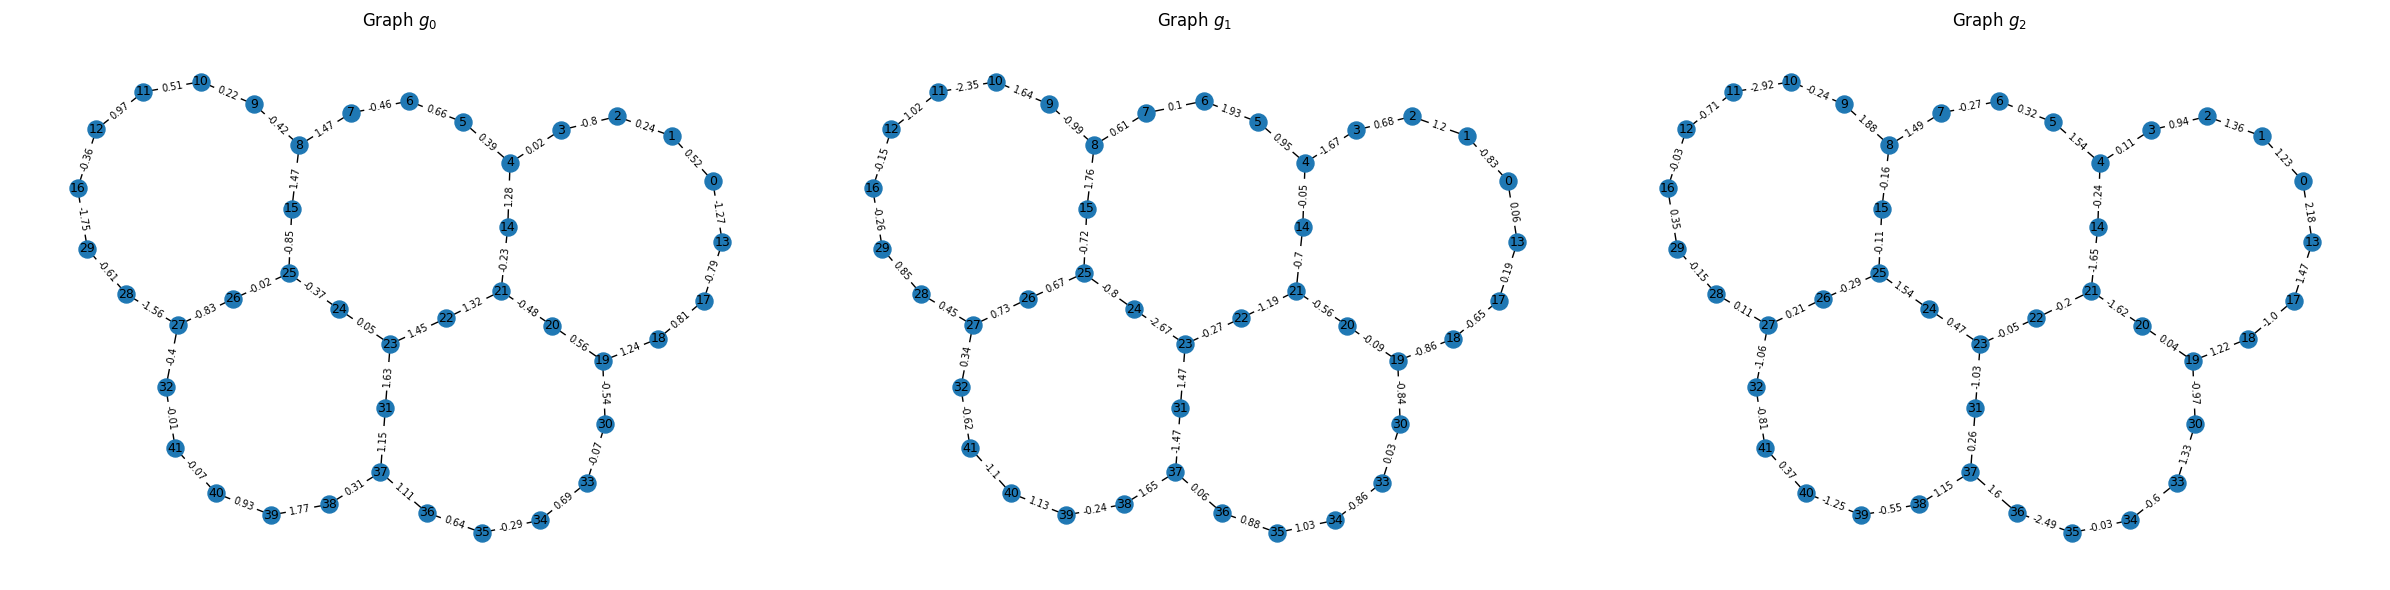

In [16]:
plot_graphs(moo_graphs)

In [17]:
#from qopt_best_practices.circuit_library import annotated_qaoa_ansatz

p_layers = 2
maxcuts = [Maxcut(g) for g in moo_graphs]
cost_ops = [to_ising(mc.to_optimization_problem())[0].simplify() for mc in maxcuts]
c_vec = ParameterVector("c", len(cost_ops))
sum_cost_op = sum(c_vec[idx] * hc for idx, hc in enumerate(cost_ops)).simplify()

# Note that we created an ansatz circuit where the individual QAOA cost and QAOA mixer layers are annotated for improved transpilation
qc = annotated_qaoa_ansatz(sum_cost_op, reps=p_layers)
qc.measure_all(inplace=True)
qc.draw(idle_wires=False,fold=-1)


┌─────── ┌───┐ ───────┐ ┌───────                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              ───────┐ ┌─────── ┌────────────┐ ───────┐ ┌───────                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [18]:
load_params_file = True

if load_params_file:
    # load low-effort QAOA parameters from file, see `else` branch for how to get advanced QAOA parameters
    params = qaoa_params[str(p_layers)]
    ansatz_qc = qc.assign_parameters(params)
else:
    # Train QAOA using the QAOA training pipeline https://github.com/qiskit-community/qaoa_training_pipeline
    from qaoa_training_pipeline.training import ScipyTrainer
    from qaoa_training_pipeline.evaluation import MPSEvaluator, StatevectorEvaluator
    
    trainer = ScipyTrainer(MPSEvaluator(bond_dim_circuit=20), minimize_args={"options": {"maxiter": 500}})
    # Use an exact simulator for small-scale quantum computations
    # trainer = ScipyTrainer(StatevectorEvaluator())

    # parameter initialization according to https://arxiv.org/pdf/2101.05742
    dt = 0.75
    grid = np.arange(1, p_layers + 1) - 0.5
    init_params = np.concatenate((1 - grid * dt / p_layers, grid * dt / p_layers))

    # `train` minimizes the cost operator, note the -1 prefactor
    training_result = trainer.train(sum(-1/len(cost_ops) * hc for hc in cost_ops).simplify(), init_params)
    params = training_result['optimized_params']
    betas = {f"β[{i}]": param for i, param in enumerate(params[:len(params)//2])}
    gammas = {f"γ[{i}]": param for i, param in enumerate(params[len(params)//2:])}
    params = betas | gammas
    ansatz_qc = qc.assign_parameters(params)
print("QAOA parameters", params)

QAOA parameters {'β[0]': 3.8473156487317204, 'β[1]': 3.679937252479205, 'γ[0]': -0.99362765274028, 'γ[1]': 0.3555146452475003}


In [19]:
# we first need to transpile the circuit before running it on a real device!
# see https://github.com/qiskit-community/qopt-best-practices/tree/main/how_tos for further transpilation improvements   
# swap strategy and coloring for native heavy-hex graphs
edge_coloring = nx.greedy_color(
    nx.line_graph(moo_graphs[0]), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))

# Make an empty swap strategy as we have a hardware-native graph here
cmap = CouplingMap(moo_graphs[0].edges())
cmap.make_symmetric()

swap_strategy = SwapStrategy(cmap, ())  # no SWAPs needed

staged_pm = generate_preset_qaoa_pass_manager(backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring)
# 4. Run the Qiskit transpilation with the above defined custom passes
isa_qc = staged_pm.run(ansatz_qc)
naive_isa_qc = generate_preset_pass_manager(backend).run(UnrollBoxes()(ansatz_qc))


print("Two-qubit gate depth", isa_qc.depth(lambda x: len(x.qubits)>1))
print("Number of two-qubit gates", isa_qc.num_nonlocal_gates())
print("Two-qubit gate depth - Naive", naive_isa_qc.depth(lambda x: len(x.qubits)>1))
print("Number of two-qubit gates - Naive", naive_isa_qc.num_nonlocal_gates())

Two-qubit gate depth 13
Number of two-qubit gates 184
Two-qubit gate depth - Naive 43
Number of two-qubit gates - Naive 184


In [20]:
# how many samples should be drawn
n_samples = 100
# how many shots per sample
shots = 100

In [21]:
# PROMPT: draw random n_samples for the n_obj-dimensional c vectors
# note that drawing from the uniform or normal distribution (with subsequent normalization)
# to get positive weights that sum up to one leads to a concentration of values around the center
def gen_cvecs(n_samples, n_obj=3):
    c_vecs = np.zeros(shape=(n_samples, n_obj+1))
    # BEGIN ANSWER, generate n_samples random n_obj-dimensional points   
    """Returns n samples uniformly distributed on a d-dimensional simplex."""

    c_vecs = np.random.dirichlet(np.ones(n_obj ), size=n_samples)

    # END ANSWER 
    return c_vecs

c_vecs = gen_cvecs(n_samples=n_samples, n_obj=n_obj)

In [22]:
gen_cvecs(10,3)
#np.mean(gen_cvecs(10,3))
#np.zeros(shape=(10, 3+1))
#np.ones(3 + 1)

array([[0.750264  , 0.04695324, 0.20278276],
       [0.55175858, 0.13373135, 0.31451007],
       [0.16347588, 0.0364234 , 0.80010071],
       [0.59831374, 0.30621099, 0.09547526],
       [0.39174647, 0.17099646, 0.43725707],
       [0.18174363, 0.73099601, 0.08726036],
       [0.45959628, 0.25045173, 0.28995199],
       [0.09168173, 0.43397503, 0.47434325],
       [0.26341947, 0.59963907, 0.13694146],
       [0.25193998, 0.19492743, 0.55313259]])

In [23]:
grade_lab_qmoo_ex1(gen_cvecs)

management.get:WARNING:2026-06-30 22:23:20,040: Loading default saved account


Grading your answer. Please wait...

Congratulations 🎉! Your answer is correct.
You scored 10 on this exercise.


In [24]:
# set error mitigation options for the sampler
options = SamplerOptions()
options.max_execution_time = 600
sampler = SamplerV2(mode=backend, options=options)
sampler.options.environment.job_tags = ["R2P_CAPSTONE"]

    
job = sampler.run([(isa_qc, c_vecs)], shots=shots)
print("Submitted job to", backend.name, "with id", job.job_id(), "and the following options")
sampler.options

Submitted job to ibm_cleveland with id d9243nnccmks73d65u50 and the following options


max_execution_time,600
default_shots,Unset
experimental,Unset
▸environment,EnvironmentOptions
log_level,'WARNING'
job_tags,['R2P_CAPSTONE']
private,False
▸simulator,SimulatorOptions
noise_model,Unset
seed_simulator,Unset
coupling_map,Unset


In [25]:
sample_res = job.result()
sample_counts = [sample_res[0].data.meas.get_counts(s) for s in range(n_samples)] 

In [26]:
# Here, we copy the string to our new location, interpret it as ASCII characters where a '0' has the value 48 and a '1' has the value 49, and get to an array of Boolean values by subtracting 48 it from it.
bitstring_length = len(next(iter(sample_counts[0].keys())))
x = np.fromiter((np.frombuffer(k.encode("ascii"), dtype="u1") - 48 for i in range(n_samples) for k in sample_counts[i].keys()), dtype=np.dtype((np.uint8, bitstring_length)))

In [27]:
# get the adjacency matrix of each graph
adj_m = [nx.adjacency_matrix(moo_graphs[i]).toarray() for i in range(n_obj)]
# compute the max-cut value for each input graph, note that `x` is a Boolean array so `1-x` is its complement, thus `x`adj_m`(1-x)` selects exactly the edges (and their weights) across the cut
fis = np.stack([np.sum((x @ adj_m[i]) * (1 - x), axis=1) for i in range(n_obj)], axis=1)
# process each sample only once 
fis = np.unique(fis, axis=0)

In [28]:
# set the reference point from which to compute the Hypervolume
hv_ref_point = np.array(lower_bound)
print("Reference Point", hv_ref_point)

num_batches = 1000 if len(fis) > 10000 else len(fis)//10
batch_size = int(len(fis)/num_batches)
hvs = []
for i in range(batch_size, len(fis), batch_size):
    # use an external library to determine the pareto front and its Hypervolume
    hv = hypervolume(fis[:i], ref=hv_ref_point, maximise=True)
    hvs.append(hv)

# included all samples in the last Hypervolume computation
hvs.append(hypervolume(fis, ref=hv_ref_point, maximise=True))


# the Pareto front is determined during the hypervolume computation, we assign it explictly here
pareto_front = filter_dominated(fis)
print("Hypervolume induced by all samples", hvs[-1])
print("The Pareto front is defined by", len(pareto_front), "points.")
print("A point of the Pareto front is", pareto_front[0])

Reference Point [-13. -20. -19.]
Hypervolume induced by all samples 26667.023856276544
The Pareto front is defined by 60 points.
A point of the Pareto front is [-5.76243387 -2.95547688  6.2320713 ]


In [29]:
grade_lab_qmoo_ex2(max(hvs))

management.get:WARNING:2026-06-30 22:24:56,259: Loading default saved account


Grading your answer. Please wait...

Congratulations 🎉! Your answer is correct.
You scored 5 on this exercise.


Text(0, 0.5, 'Hypervolume')

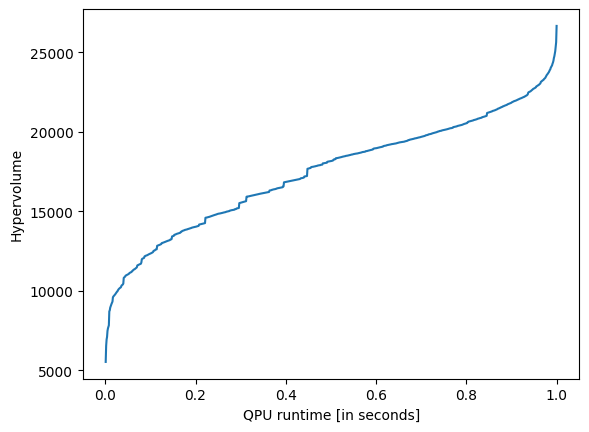

In [30]:
# we assume a 10kHz sampling rate
qpu_freq = 10000
time_per_sample = batch_size/qpu_freq
max_hvs = [hvs[i] for i in range(len(hvs))]
seconds = [time_per_sample*(i+1) for i in range(len(hvs))]

plt.plot(seconds, max_hvs)
plt.xlabel("QPU runtime [in seconds]")
plt.ylabel("Hypervolume")

loading ./3_regular_static_80q/problem_graph_*.json


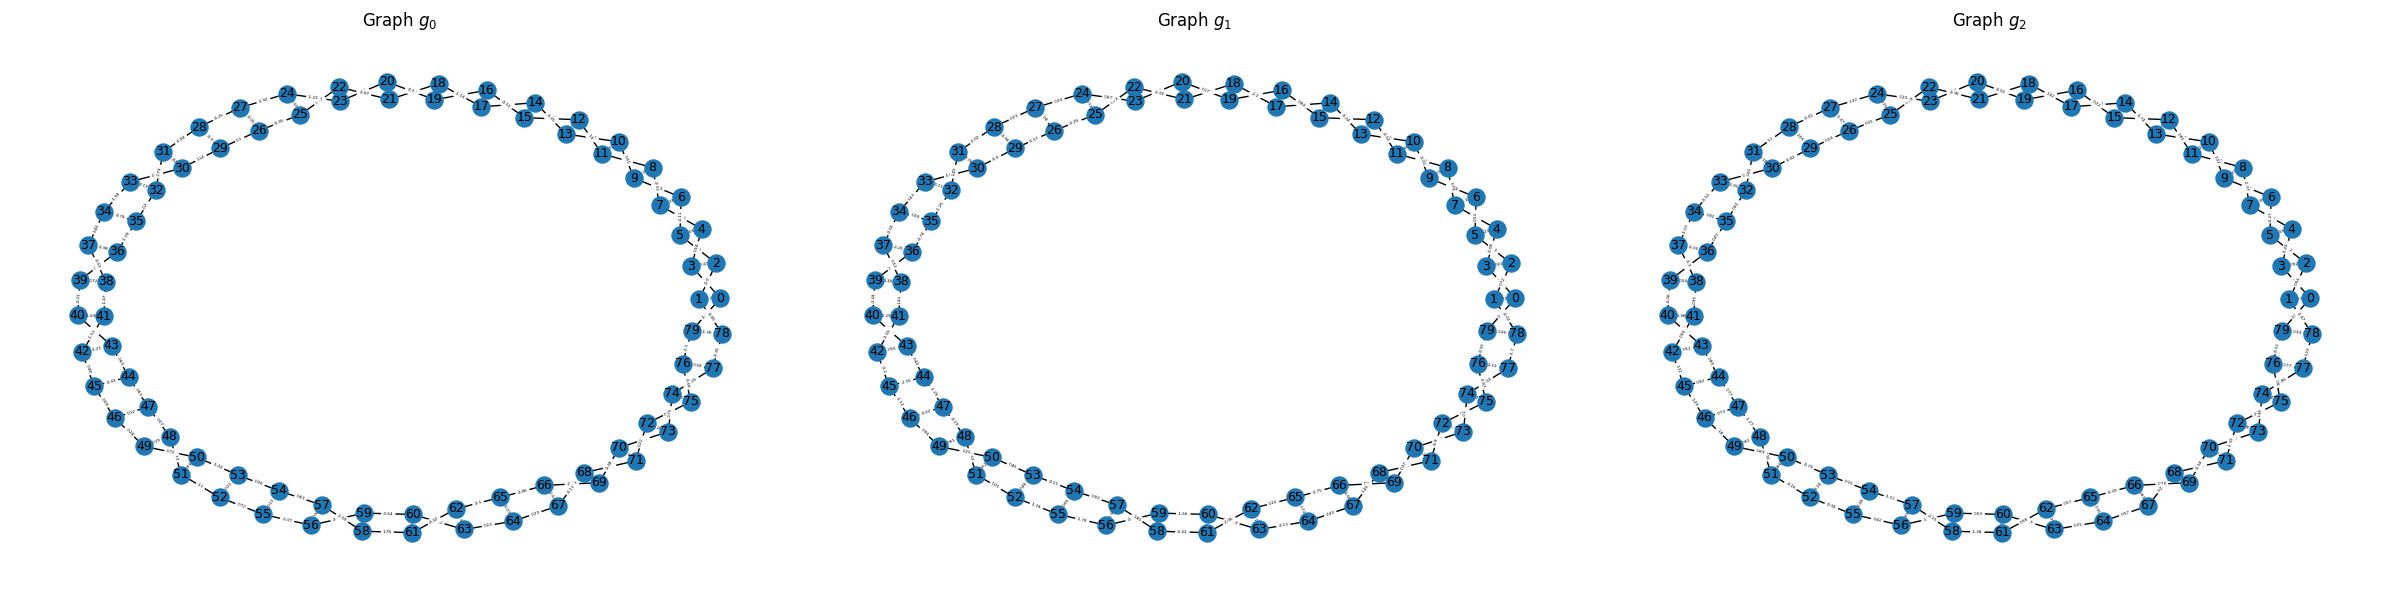

In [31]:
# Note that the QAOA parameters loaded from file here are determined by a coarse simulation and can likely be improved
# you can find 12-node graphs at "./instances/3_regular_static_12q/" and "./instances/circle_12q/" for prototyping purposes
moo_graphs, qaoa_params, upper_bounds, lower_bounds = load_problem("./3_regular_static_80q/")

plot_graphs(moo_graphs)

In [32]:
# PROMPT
# 1a) Prepare the Ansatz circuit
# BEGIN ANSWER
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz

n_obj = len(moo_graphs)
p_layers = 1

maxcuts = [Maxcut(g) for g in moo_graphs]
cost_ops = [to_ising(mc.to_optimization_problem())[0].simplify() for mc in maxcuts]

c_vec = ParameterVector("c", len(cost_ops))
sum_cost_op = sum(c_vec[idx] * hc for idx, hc in enumerate(cost_ops)).simplify()

qc = annotated_qaoa_ansatz(sum_cost_op, reps=p_layers)
qc.measure_all(inplace=True)
# END ANSWER

In [33]:
# PROMPT
# 1b) Train the Ansatz parameters or use qaoa_params
# qaoa_params is a dictionary that contains the QAOA \beta-, and
#  \gamma-parameters for p=1 and p=2 QAOA layers, i.e. {"1": {"\beta[0]": ...}}, "2": {"\beta[0]": ..., "\beta[1]": ...}
# BEGIN ANSWER
params = qaoa_params[str(p_layers)]
ansatz_qc = qc.assign_parameters(params)
# END ANSWER

In [34]:
# PROMPT
# 2) Transpile the Ansatz circuit [10 pts]
# BEGIN ANSWER
isa_qc = generate_preset_qaoa_pass_manager(backend)
isa_qc = staged_pm.run(ansatz_qc)
# END ANSWER

TypeError: generate_preset_qaoa_pass_manager() missing 1 required positional argument: 'swap_strategy'

In [ ]:
grade_lab_qmoo_ex3(isa_qc)

In [ ]:
# PROMPT
# 3) Generate weight vectors `c_vecs` and sample from the Ansatz circuit
# BEGIN ANSWER
n_samples = 100
shots = 100

c_vecs = gen_cvecs(n_samples=n_samples, n_obj=n_obj)

options = SamplerOptions()
options.max_execution_time = 600

sampler = SamplerV2(mode=backend, options=options)
sampler.options.environment.job_tags = ["R2P_CAPSTONE"]

job = sampler.run([(isa_qc, c_vecs)], shots=shots)
sample_res = job.result()
sample_counts = [sample_res[0].data.meas.get_counts(s) for s in range(n_samples)]
# END ANSWER

In [ ]:
# PROMPT
# 4) Post-process the samples into the Hypervolume / Pareto front
# BEGIN ANSWER
bitstring_length = len(next(iter(sample_counts[0].keys())))
x = np.fromiter(
    (
        np.frombuffer(k.encode("ascii"), dtype="u1") - 48
        for i in range(n_samples)
        for k in sample_counts[i].keys()
    ),
    dtype=np.dtype((np.uint8, bitstring_length))
)

adj_m = [nx.adjacency_matrix(moo_graphs[i]).toarray() for i in range(n_obj)]
fis = np.stack(
    [np.sum((x @ adj_m[i]) * (1 - x), axis=1) for i in range(n_obj)],
    axis=1
)
fis = np.unique(fis, axis=0)

hv_ref_point = np.array(lower_bounds)

num_batches = 1000 if len(fis) > 10000 else max(1, len(fis) // 10)
batch_size = max(1, int(len(fis) / num_batches))

hvs = []
for i in range(batch_size, len(fis), batch_size):
    hvs.append(hypervolume(fis[:i], ref=hv_ref_point, maximise=True))

hvs.append(hypervolume(fis, ref=hv_ref_point, maximise=True))
pareto_front = filter_dominated(fis)

qpu_freq = 10000
time_per_sample = batch_size / qpu_freq
seconds = [time_per_sample * (i + 1) for i in range(len(hvs))]
# END ANSWER

In [ ]:
from qc_grader.challenges.r2p_2026_us import check_progress
check_progress()